In [9]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.1 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.0 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ------ --------------------------------- 6.3/36.6 MB 29.6 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/36.6 MB 29.2 MB/s eta 0:00:01
   -------------------- ------------------- 18.9/36.6 MB 29.0 MB/s eta 0:00:01
   --------------------------- ------------ 25.4/36.6 MB 29.3 MB/s eta 0:00:01
   ---------------------------------- ----- 32.0/36.6 MB 29.8 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6


Pesos Iniciales
Weights: [[ 0.   0. ]
 [ 0.   0. ]
 [-0.1 -0.1]]
Bias: [-0.1  0.   0. ]

Época 1
Predicciones: [350 200 200 200]
Error: 1
Weights: [[ 0.   0. ]
 [ 0.   0. ]
 [-0.1 -0.1]]
Bias: [-0.2  0.   0.1]

Época 2
Predicciones: [350 200 200 200]
Error: 1
Weights: [[ 0.1  0. ]
 [ 0.   0. ]
 [-0.1 -0.2]]
Bias: [-0.2  0.   0.1]

Época 3
Predicciones: [350 200 200 200]
Error: 1
Weights: [[ 0.1  0. ]
 [ 0.   0. ]
 [-0.2 -0.2]]
Bias: [-0.3  0.   0.1]

Época 4
Predicciones: [350 200 200  50]
Error: 0
Weights: [[ 0.2  0.1]
 [ 0.   0. ]
 [-0.2 -0.2]]
Bias: [-0.2  0.   0.1]
Condiccion de paro: Disparada.

Pesos Finales
Weights: [[ 0.2  0.1]
 [ 0.   0. ]
 [-0.2 -0.2]]
Bias: [-0.2  0.   0.1]


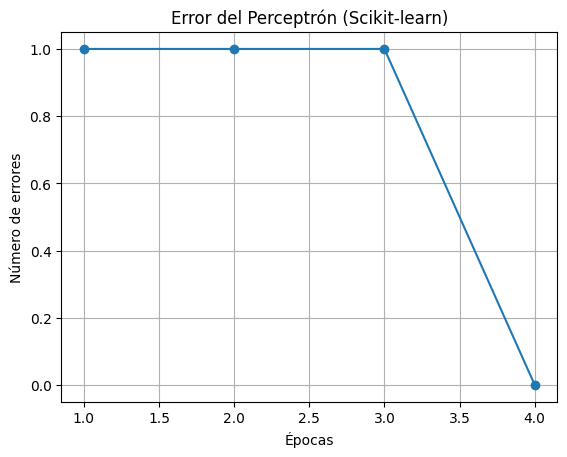

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

# hiperparametros
inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
targets = np.array([350,200,200,50])

# Modelo
modelo = Perceptron(eta0=0.1, max_iter=1, warm_start=True)
#eta = indice de aprendizaje
#max iter = no repita entradas tipo 0,0 o 0,1   #Hiperparametros
#war start=  recordar valores

epochs = 15 #epocas
errores = []


modelo.partial_fit(inputs, targets, classes=np.array([350,200,50])) # partial = mostrar cambios con cada epoca

print("\nPesos Iniciales")
print("Weights:", modelo.coef_)
print("Bias:", modelo.intercept_)

#agregar condicion de paro
condicion_paro = False

#aprendizaje
for epoch in range(epochs):
    modelo.partial_fit(inputs, targets)

    predicciones = modelo.predict(inputs)
    error = np.sum(predicciones != targets)
    errores.append(error)

 # ver epocas
    print(f"\nÉpoca {epoch+1}")
    print("Predicciones:", predicciones)
    print("Error:", error)
    print("Weights:", modelo.coef_)
    print("Bias:", modelo.intercept_)

    # Verificar condición de paro
    if error == 0:
        condicion_paro = True
        print("Condiccion de paro: Disparada.")
        break
    

#Finales
print("\nPesos Finales")
print("Weights:", modelo.coef_)
print("Bias:", modelo.intercept_)

plt.figure()
plt.plot(range(1, len(errores)+1), errores, marker='o')
plt.xlabel("Épocas")
plt.ylabel("Número de errores")
plt.title("Error del Perceptrón (Scikit-learn)")
plt.grid()
plt.show()